# Wind Calibration Tutorial

This notebook shows a practical end-to-end workflow for running wind calibration locally with `WindCalibrator` and checking the generated output files.


## 1) Environment and Setup 

Before running the notebook:

- Use Python 3.12.
- Install project dependencies (including notebook extras): `uv sync --group notebook`. This should be executed in the terminal window.
- Ensure NetCDF support is available (`xarray` + `netCDF4`) because ERA5 loading and ingestion depends on it.

> If `uv` is not available in your environment, install dependencies with your standard Python package workflow.

In [62]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

from weather.calibration.wind.wind_calibrator import WindCalibrator

## 2) Required Input Folder Structure and Files

`WindCalibrator` expects a base `data_path` with these subfolders:

- `plant/plant_data.csv`
- `generation/generation_data.parquet`
- `era5/*.nc` (one or more ERA5 NetCDF files)

In [63]:
DATA_PATH = Path('data')
OUTPUT_PATH = Path('outputs/wind_calibration')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print('Data path:', DATA_PATH.resolve())
print('Output path:', OUTPUT_PATH.resolve())

Data path: /Users/matthewcampbell/Weather Repo/weather/data
Output path: /Users/matthewcampbell/Weather Repo/weather/outputs/wind_calibration


## 3) Downloading the Calibration Inputs

The calibration workflow needs three input datasets:

1. **Plant data**: Plant metadata and CfD/BMU mapping. Ingested through the `CfDDataDownloader` via an API from the Low Carbon Contracts Company (LCCC)
2. **Generation data**: Historical generation for those plants. Ingested through the `GenerationDataDownloader` via an API from Elexon BMRS.
3. **ERA5 weather data**: Hourly reanalysis weather data in NetCDF format. Ingested through the `ERA5DataDownloader` from the Copernicus Climate Data Store via `cdsapi`

This repository provides a `DownloadManager` that downloads and saves these inputs into the expected folder structure under `data/`:

- `data/plant/`
- `data/generation/`
- `data/era5/`

> Note: ERA5 downloads require a valid `CDS_API_KEY`. This can be saved in .env-example

In [64]:
from weather.core.data_downloader import DownloadManager

In [65]:
dm = DownloadManager()

# Download everything needed for calibration
dm.download_all()

[INFO] - Loading CfD plant data with BMU mapping... - [data_downloader] - 2026-05-14 13:46:31
[INFO] - Found 10 unique BMU IDs. - [data_downloader] - 2026-05-14 13:46:31


[INFO] - Processing ERA5 data:   0%|                    | 0/4 [00:00<?, ?year/s] , downloading file for 2023 - [data_downloader] - 2026-05-14 13:46:31

[INFO] - Downloading ERA5 data for 2023... - [data_downloader] - 2026-05-14 13:46:31
[ERROR] - CDS API key not found in environment variables. - [data_downloader] - 2026-05-14 13:46:31
[ERROR] - Error initializing CDS API client: CDS API key missing. Set CDS_API_KEY or pass api_key to ERA5DataDownloader. - [data_downloader] - 2026-05-14 13:46:31
[ERROR] - Error downloading 2023: CDS API key missing. Set CDS_API_KEY or pass api_key to ERA5DataDownloader. - [data_downloader] - 2026-05-14 13:46:31


[INFO] - Processing ERA5 data:   0%|                    | 0/4 [00:00<?, ?year/s] , downloading file for 2023 - [data_downloader] - 2026-05-14 13:46:31


ValueError: CDS API key missing. Set CDS_API_KEY or pass api_key to ERA5DataDownloader.

### Optional: download data step-by-step instead of all at once

In [68]:
dm = DownloadManager()

# 1. Download plant metadata / CfD mapping
dm.download_cfd()

# 2. Download generation data for those plants in CfD metadata
dm.download_generation_data()

# 3. Download ERA5 weather data
dm.download_era5()

[INFO] - Loading CfD plant data with BMU mapping... - [data_downloader] - 2026-05-14 13:48:20
[INFO] - Found 127 unique BMU IDs. - [data_downloader] - 2026-05-14 13:48:20
[INFO] - Downloading generation data for CfD-associated BMUs... - [data_downloader] - 2026-05-14 13:48:20
[INFO] - Fetching settled Elexon generation data from https://data.elexon.co.uk/bmrs/api/v1/datasets/B1610/stream... - [data_downloader] - 2026-05-14 13:48:20
[INFO] - Loaded 2739672 records into dataframe memory. - [data_downloader] - 2026-05-14 13:49:36
[WARNING] - Unexpected settlement period counts: {'2026-05-06': 30} - [data_downloader] - 2026-05-14 13:49:44
[INFO] - Generation data saved to /Users/matthewcampbell/Weather Repo/weather/data/generation/generation_data.parquet - [data_downloader] - 2026-05-14 13:49:47


In [ ]:
# add a log of the data downloaded (years etc)

### Pre-Check: verify that all data has been downloaded



In [69]:
required_files = [
    DATA_PATH / 'plant' / 'plant_data.csv',
    DATA_PATH / 'generation' / 'generation_data.parquet',
]
required_dirs = [DATA_PATH / 'plant', DATA_PATH / 'generation', DATA_PATH / 'era5']

for d in required_dirs:
    print(f'{d}:', 'Exists' if d.exists() else 'MISSING')

for f in required_files:
    print(f'{f}:', 'Exists' if f.exists() else 'MISSING')

era5_files = sorted((DATA_PATH / 'era5').glob('*.nc'))
print('ERA5 files found:', len(era5_files))
for path in era5_files[:10]:
    print(' -', path.name)
if len(era5_files) > 10:
    print(f' ... and {len(era5_files) - 10} more')

data/plant: Exists
data/generation: Exists
data/era5: Exists
data/plant/plant_data.csv: Exists
data/generation/generation_data.parquet: Exists
ERA5 files found: 555
 - ERA5_wind_1980_01.nc
 - ERA5_wind_1980_02.nc
 - ERA5_wind_1980_03.nc
 - ERA5_wind_1980_04.nc
 - ERA5_wind_1980_05.nc
 - ERA5_wind_1980_06.nc
 - ERA5_wind_1980_07.nc
 - ERA5_wind_1980_08.nc
 - ERA5_wind_1980_09.nc
 - ERA5_wind_1980_10.nc
 ... and 545 more


### Optional pre-check: verify ERA5 NetCDF can be opened

If this fails, calibration will fail during ERA5 loading.

In [56]:
if era5_files:
    test_file = era5_files[0]
    print('Testing ERA5 file:', test_file)
    try:
        ds = xr.open_dataset(test_file, engine='netcdf4')
        print('Opened successfully. Variables:', list(ds.data_vars)[:10])
        ds.close()
    except Exception as exc:
        print('Failed to open ERA5 file with netcdf4:', exc)
else:
    print('No ERA5 files found. Add .nc files under data/era5/.')

Testing ERA5 file: data/era5/ERA5_wind_1980_01.nc
Failed to open ERA5 file with netcdf4: unrecognized engine netcdf4 must be one of: ['scipy', 'store']


## 4) Import and Configure `WindCalibrator`

The key arguments are:

- `data_path`: base folder containing `plant/`, `generation/`, `era5/`
- `output_path`: where calibration outputs are written
- `visual_output`: save power curve PNG plots when `True`
- `stream_npy_output`: also save `Wind Streams.npy` when `True`

In [70]:
wc = WindCalibrator(
    data_path=str(DATA_PATH),
    output_path=OUTPUT_PATH,
    visual_output=True,
    stream_npy_output=True,
)
wc

[INFO] - Plant data loaded: 144 plants, 22609.6 MW total capacity - [data_loader] - 2026-05-14 13:50:26
[INFO] - Generation data loaded: 1162397 records, 48 plants - [data_loader] - 2026-05-14 13:50:26


/Users/matthewcampbell/Weather Repo/weather/weather/core/data_loader.py:308: UserWarning: rename 'time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({time_dim: "time"})
/Users/matthewcampbell/Weather Repo/weather/weather/core/data_loader.py:308: UserWarning: rename 'time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({time_dim: "time"})
/Users/matthewcampbell/Weather Repo/weather/weather/core/data_loader.py:308: UserWarning: rename 'time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({time_dim: "time"})
/Users/matthewcampbell/Weather Repo/weather/weather/core/data_loader.py:308: UserWarning: rename 'time' to 'time' does not create an index anymore. Try using swap_dims inst

[INFO] - ERA5 data loaded: 555 files, 405408 time periods - [data_loader] - 2026-05-14 13:51:33


## 5) Run Calibration

This executes the full workflow and writes outputs to `output_path`. Add more explanation on what calibration is doing, logistic functions

In [71]:
wc.calibrate()

[INFO] - Starting calibration process... - [wind_calibrator] - 2026-05-14 13:51:45
[INFO] - Extracting resource data for plants... - [wind_calibrator] - 2026-05-14 13:52:03
[INFO] - Written plant-wise resource dataset to outputs/wind_calibration/Wind Speeds.csv - [wind_calibrator] - 2026-05-14 13:53:07
[INFO] - Clculating historical load factors... - [wind_calibrator] - 2026-05-14 13:53:08
[INFO] - Fitting probability distribution to historical load factors... - [wind_calibrator] - 2026-05-14 13:53:11
[INFO] - Written historical load factor parameters to outputs/wind_calibration/Weibull Params.csv - [wind_calibrator] - 2026-05-14 13:53:12
[INFO] - Estimating long-term load factors for plants... - [wind_calibrator] - 2026-05-14 13:53:12
[INFO] - AAA-ACH-183 - [wind_calibrator] - 2026-05-14 13:53:13
[INFO] - AAA-BAD-185 - [wind_calibrator] - 2026-05-14 13:53:14
[INFO] - AAA-BAN-189 - [wind_calibrator] - 2026-05-14 13:53:14
[INFO] - AAA-BAN-192 - [wind_calibrator] - 2026-05-14 13:53:15
[I

## 6) Inspect Generated Outputs

After calibration completes, this notebook should produce:

- `Calibration Summary.csv`
- `Weibull Params.csv`
- `Wind Speeds.csv`
- `Wind Streams.parquet`
- `PowerCurveFit_*.png` (if `visual_output=True`)
- `Wind Streams.npy` (if `stream_npy_output=True`)

In [24]:
# list of the generated outputs
sorted([p.name for p in OUTPUT_PATH.glob('*')])

['Calibration Summary.csv',
 'PowerCurveFit_AAA-COI-196.png',
 'PowerCurveFit_AAA-DOR-182.png',
 'PowerCurveFit_AR2-HRN-106.png',
 'PowerCurveFit_AR2-MRY-307.png',
 'PowerCurveFit_CAA-EAS-166.png',
 'PowerCurveFit_INV-WAL-002.png',
 'Weibull Params.csv',
 'Wind Speeds.csv',
 'Wind Streams.npy',
 'Wind Streams.parquet']

### Output: 1 - Calibration Summary

Calibration summary CSV containing 5-parameters function parameters and generator estimated load factors

In [50]:
summary = pd.read_csv(OUTPUT_PATH / 'Calibration Summary.csv')

display(summary)

,PLANT ID,a,b,c,d,g,Estimated Load Factor
0,AAA-COI-196,0.0,2.944727,50.000000,1.0,132.017650,0.4047
1,AAA-DOR-182,0.0,6.703886,0.317161,1.0,0.021343,0.3663
2,AR2-HRN-106,0.0,7.259315,7.818244,1.0,0.385119,0.5874
3,AR2-MRY-307,0.0,11.310561,4.276672,1.0,0.186679,0.8086
4,CAA-EAS-166,0.0,3.680129,33.077840,1.0,499.999700,0.8744
5,INV-WAL-002,0.0,4.465264,12.989685,1.0,3.002939,0.6256
6,Generic Offshore Wind,0.0,6.678818,14.540610,1.0,125.893610,0.0000
7,Generic Onshore Wind,0.0,4.824306,25.158580,1.0,66.019500,0.0000


### Output: 2 - Weibull Parameters

Weilbull Parameters CSV displaying each wind farms parameters k and λ of the Weibull distribution of the wind speed frequency.

In [49]:
weibull = pd.read_csv(OUTPUT_PATH / 'Weibull Params.csv')

display(weibull)

,plant_id,wind_speed_mean,wind_speed_stdev,k,lambda
0,AAA-COI-196,7.452876,3.094071,2.585561,8.397915
1,INV-WAL-002,11.764718,4.966975,2.550471,13.250903
2,AR2-HRN-106,12.242567,5.123046,2.605867,13.767497
3,AR2-MRY-307,11.534141,3.728977,3.353186,12.832122
4,AAA-DOR-182,8.297526,2.689894,3.344885,9.233101
5,CAA-EAS-166,11.724314,5.208889,2.430958,13.218467


### Output: 3 - Wind Speeds

Hourly windspeeds from 1980-01-01 to present for each plant_id

In [51]:
wind_speeds = pd.read_csv(OUTPUT_PATH / 'Wind Speeds.csv')

display(wind_speeds)

,time,plant_id,wind_speed
0,1980-01-01 00:00:00+00:00,AAA-COI-196,3.648929
1,1980-01-01 00:00:00+00:00,AAA-BAN-190,7.480757
2,1980-01-01 00:00:00+00:00,INV-WAL-002,4.150958
3,1980-01-01 00:00:00+00:00,AR2-HRN-106,11.570215
4,1980-01-01 00:00:00+00:00,AR2-MRY-307,9.994375
...,...,...,...
4054075,2026-03-31 23:00:00+00:00,AAA-DOR-182,6.670497
4054076,2026-03-31 23:00:00+00:00,AAA-SNE-179,6.968460
4054077,2026-03-31 23:00:00+00:00,AAA-BRE-177,3.773824
4054078,2026-03-31 23:00:00+00:00,AR4-HHR-610,6.099486


### Output: 4 - Wind Streams

Hourly wind streams (Load Factors) from 1980-01-01 to present for each plant_id

In [52]:
wind_streams = pd.read_parquet(OUTPUT_PATH / 'Wind Streams.parquet')

display(wind_streams)

,Times,AAA-BAN-190,AAA-BRE-177,AAA-COI-196,AAA-DOR-182,AAA-SNE-179,AR2-HRN-106,AR2-MRY-307,AR4-HHR-610,CAA-EAS-166,INV-WAL-002
0,1980-01-01 00:00:00+00:00,0.172729,0.001094,0.057563,0.324649,0.000371,0.672934,0.833424,0.002217,0.999997,0.018194
1,1980-01-01 01:00:00+00:00,0.180582,0.001207,0.053839,0.325682,0.000558,0.612914,0.840303,0.002467,0.999990,0.025110
2,1980-01-01 02:00:00+00:00,0.163559,0.000985,0.044354,0.328694,0.000421,0.566819,0.837954,0.002032,0.999986,0.020749
3,1980-01-01 03:00:00+00:00,0.138758,0.000532,0.043854,0.332553,0.000330,0.557562,0.841966,0.002234,0.999979,0.018191
4,1980-01-01 04:00:00+00:00,0.129600,0.000411,0.048772,0.333441,0.000183,0.555983,0.847374,0.001327,0.999987,0.012378
...,...,...,...,...,...,...,...,...,...,...,...
405403,2026-03-31 19:00:00+00:00,0.055315,0.011864,0.463347,0.339818,0.158594,0.000712,0.851091,0.107515,0.003132,0.215453
405404,2026-03-31 20:00:00+00:00,0.060883,0.008533,0.466437,0.343181,0.147476,0.010460,0.853856,0.102814,0.001048,0.232440
405405,2026-03-31 21:00:00+00:00,0.050092,0.006184,0.446817,0.343562,0.109491,0.053445,0.856083,0.069752,0.002972,0.268850
405406,2026-03-31 22:00:00+00:00,0.049450,0.006657,0.475937,0.348869,0.119230,0.082084,0.850749,0.068284,0.021612,0.299736


### Output: 5 - Power Curves

Wind power curve plot outputs showing the relationship between wind speed and load factor for each plant_id, with fitted power curves alongside average wind speed profiles.

Found 6 PNG files.



### PowerCurveFit_AAA-COI-196.png

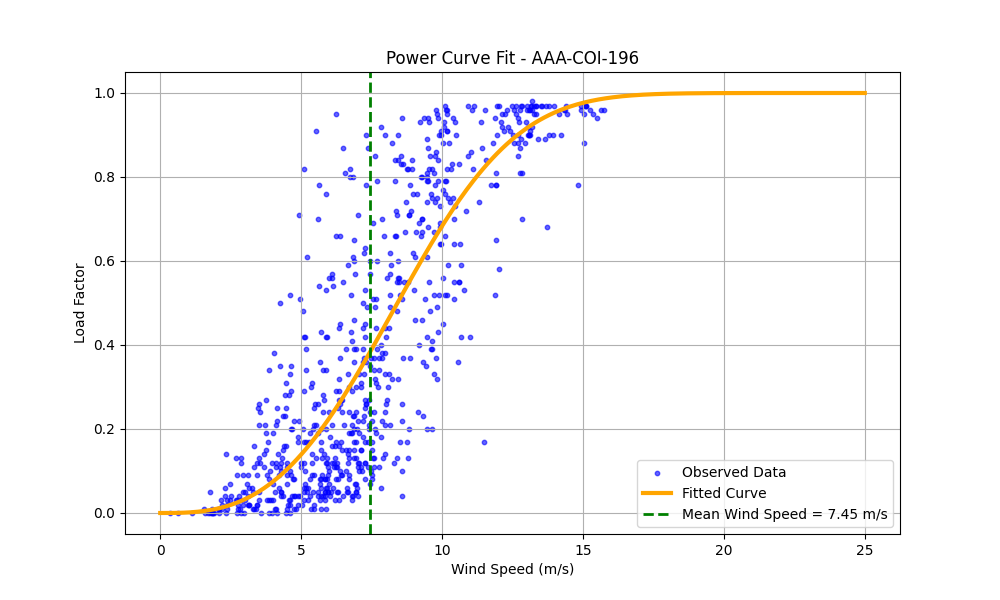

### PowerCurveFit_AAA-DOR-182.png

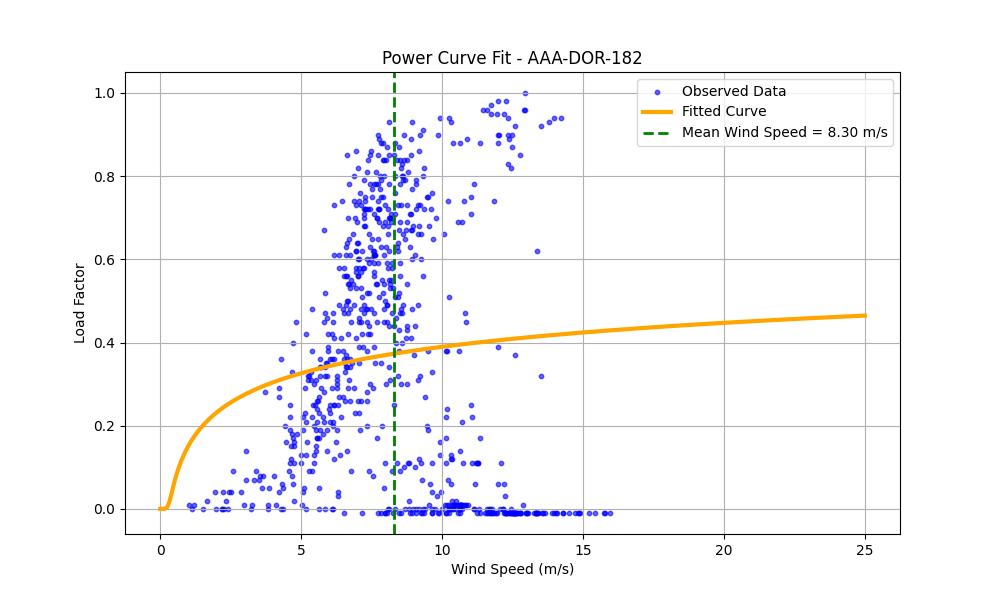

### PowerCurveFit_AR2-HRN-106.png

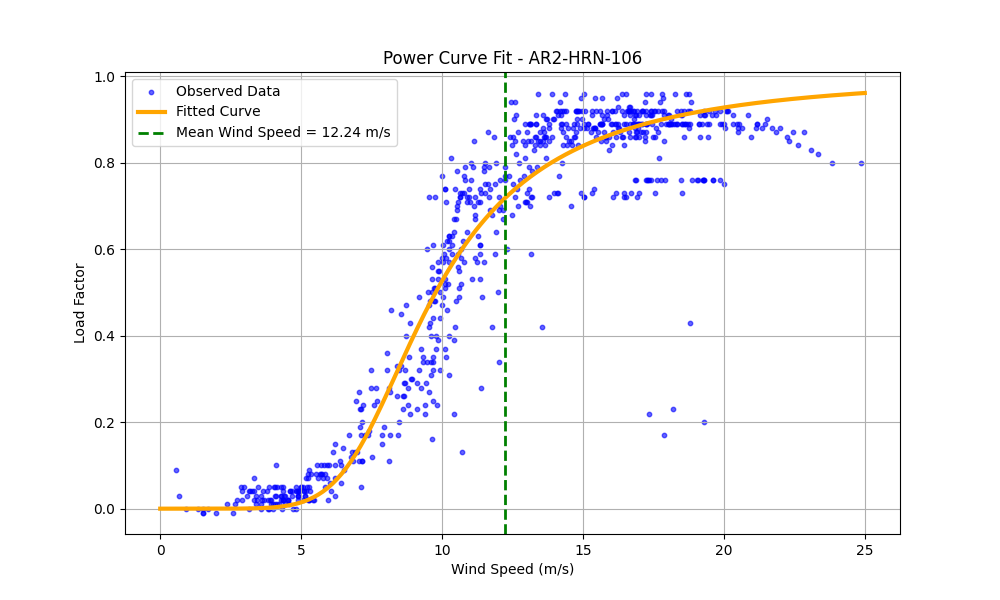

### PowerCurveFit_AR2-MRY-307.png

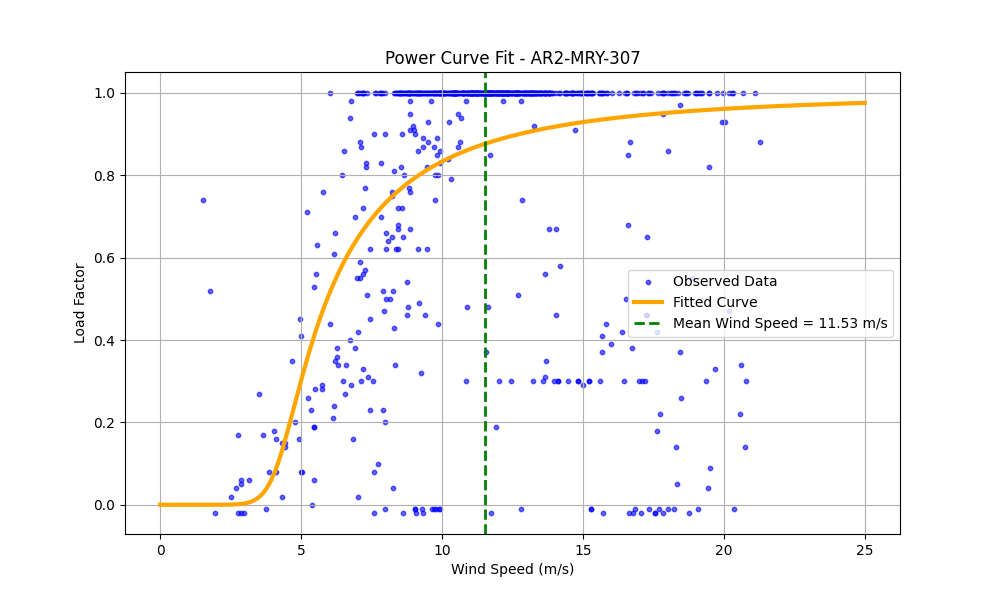

### PowerCurveFit_CAA-EAS-166.png

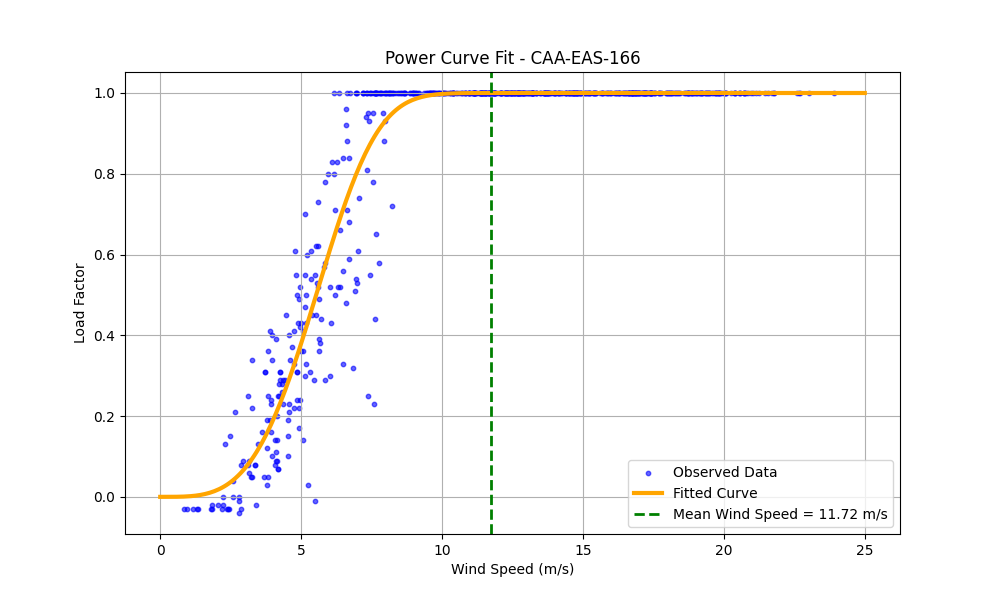

### PowerCurveFit_INV-WAL-002.png

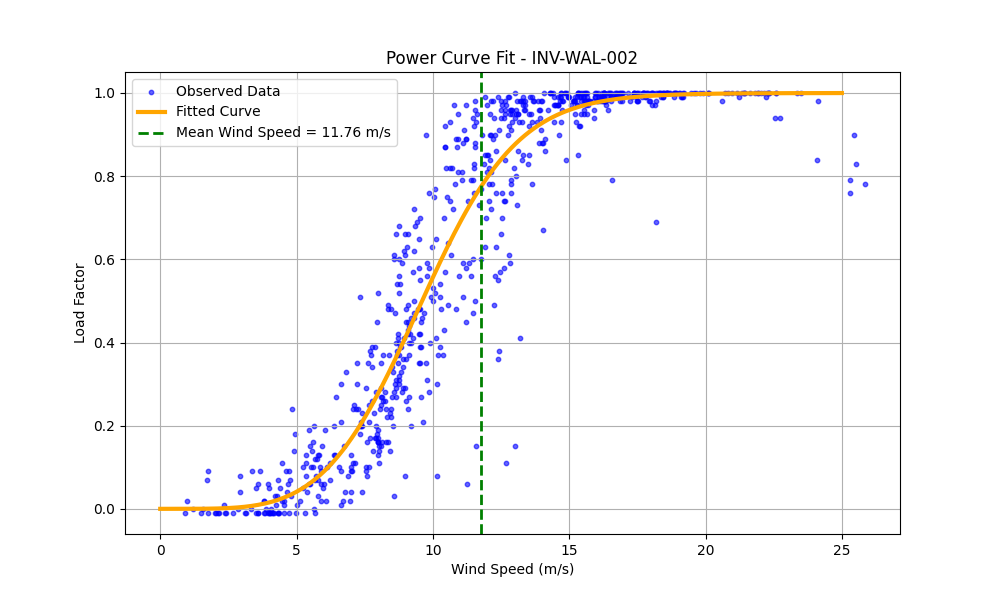

In [47]:
from pathlib import Path
from IPython.display import Image, display, Markdown

png_files = sorted(Path(OUTPUT_PATH).glob("PowerCurveFit_*.png"))

if not png_files:
    print("No PNG files found.")
else:
    print(f"Found {len(png_files)} PNG files.\n")
    for png in png_files:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png)))

## 7) Basic Troubleshooting

### ERA5 / NetCDF loading issues

If you see warnings like "Failed to load ... xarray IO backends ...":

1. Confirm dependencies are installed (including notebook extras):
   - `uv sync --group notebook`
2. Verify `netCDF4` is importable and print versions:
3. Try opening one ERA5 file with `engine='netcdf4'` (cell above).
4. Confirm `.nc` files are in `data/era5/` and not corrupted.

If no files load successfully, `WindCalibrator` raises: `ValueError: Failed to load any NetCDF files successfully`.

In [48]:
import importlib

for pkg in ['xarray', 'netCDF4', 'h5netcdf']:
    spec = importlib.util.find_spec(pkg)
    print(f'{pkg}:', 'installed' if spec else 'missing')

xarray: installed
netCDF4: missing
h5netcdf: missing


### Other quick checks

- Missing plant file: `data/plant/plant_data.csv`
- Missing generation file: `data/generation/generation_data.parquet`
- Missing ERA5 directory/files: `data/era5/*.nc`
- Permission issues writing output: ensure `output_path` is writable